## Skin Cancer Detection using Transfer Learning Technique in TensorFlow

### 1. Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

### 2. Loading Dataset

In [5]:
!kaggle datasets download -d shashanks1202/skin-cancer-dataset

Dataset URL: https://www.kaggle.com/datasets/shashanks1202/skin-cancer-dataset
License(s): MIT
100% 6.29M/6.29M [00:00<00:00, 45.9MB/s]



In [6]:
!unzip skin-cancer-dataset.zip

Archive:  skin-cancer-dataset.zip
  inflating: train_cancer/benign/12.jpg  
  inflating: train_cancer/benign/13.jpg  
  inflating: train_cancer/benign/14.jpg  
  inflating: train_cancer/benign/17.jpg  
  inflating: train_cancer/benign/19.jpg  
  inflating: train_cancer/benign/20.jpg  
  inflating: train_cancer/benign/21.jpg  
  inflating: train_cancer/benign/22.jpg  
  inflating: train_cancer/benign/23.jpg  
  inflating: train_cancer/benign/24.jpg  
  inflating: train_cancer/benign/25.jpg  
  inflating: train_cancer/benign/26.jpg  
  inflating: train_cancer/benign/27.jpg  
  inflating: train_cancer/benign/28.jpg  
  inflating: train_cancer/benign/29.jpg  
  inflating: train_cancer/benign/3.jpg  
  inflating: train_cancer/benign/30.jpg  
  inflating: train_cancer/benign/32.jpg  
  inflating: train_cancer/benign/33.jpg  
  inflating: train_cancer/benign/34.jpg  
  inflating: train_cancer/benign/35.jpg  
  inflating: train_cancer/benign/36.jpg  
  inflating: train_cancer/benign/38.jpg  
 

In [10]:
from glob import glob

images = glob('train_cancer/*/*.jpg')
print(len(images))

270


### 3. Data Preprocessing

In [11]:
#replace backslash with forward slash to avoid unexpected errors
images = [path.replace('\\', '/') for path in images]
df = pd.DataFrame({'filepath': images})
df['label'] = df['filepath'].str.split('/', expand=True)[1]
df.head()

,filepath,label
0,train_cancer/benign/42.jpg,benign
1,train_cancer/benign/21.jpg,benign
2,train_cancer/benign/29.jpg,benign
3,train_cancer/benign/35.jpg,benign
4,train_cancer/benign/17.jpg,benign


In [12]:
df['label_bin'] = np.where(df['label'].values == 'malignant', 1, 0)
df.head()

,filepath,label,label_bin
0,train_cancer/benign/42.jpg,benign,0
1,train_cancer/benign/21.jpg,benign,0
2,train_cancer/benign/29.jpg,benign,0
3,train_cancer/benign/35.jpg,benign,0
4,train_cancer/benign/17.jpg,benign,0


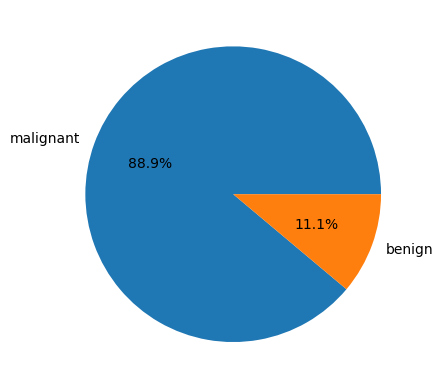

In [13]:
x = df['label'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

/tmp/ipykernel_638/382692412.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image_path = data[0]


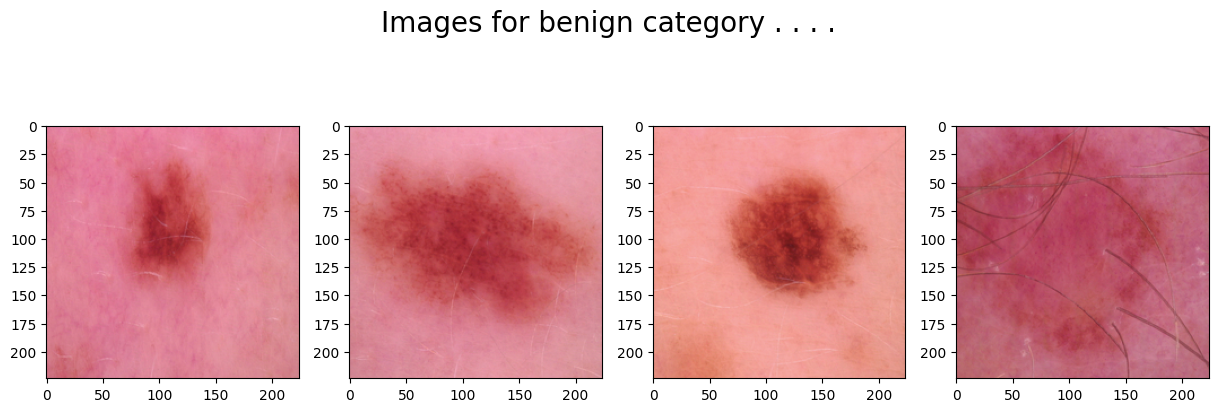

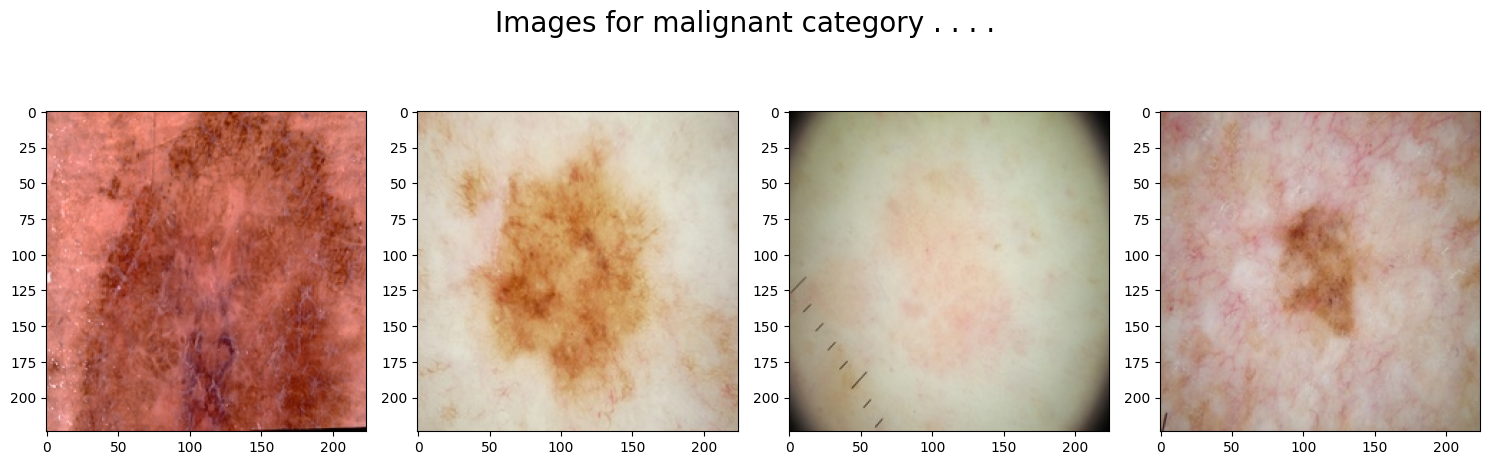

In [15]:
from PIL import Image

for cat in df['label'].unique():
    temp = df[df['label'] == cat]

    index_list = temp.index
    fig, ax = plt.subplots(1, 4, figsize=(15, 5))
    fig.suptitle(f'Images for {cat} category . . . .', fontsize=20)
    for i in range(4):
        index = np.random.randint(0, len(index_list))
        index = index_list[index]
        data = df.iloc[index]

        image_path = data[0]

        img = np.array(Image.open(image_path))
        ax[i].imshow(img)
plt.tight_layout()
plt.show()

1. Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

features = df['filepath']
target = df['label_bin']

X_train, X_val, y_train, y_val = train_test_split(features, target, test_size=0.15, random_state=10)

X_train.shape, X_val.shape

((229,), (41,))

In [17]:
def decode_image(filepath, label=None):

	img = tf.io.read_file(filepath)
	img = tf.image.decode_jpeg(img)
	img = tf.image.resize(img, [224, 224])
	img = tf.cast(img, tf.float32) / 255.0

	# Compare label with integer 0 or 1 instead of string
	if label == 0: 
		Label = 0
	else:
		Label = 1

	return img, Label
  
# This code is modified by Susobhan Akhuli

In [19]:
import tensorflow as tf

AUTO = tf.data.experimental.AUTOTUNE

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .map(decode_image, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .map(decode_image, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

### 4. Build the Model

In [20]:
from tensorflow.keras.applications.efficientnet import EfficientNetB7

pre_trained_model = EfficientNetB7(
    input_shape=(224, 224, 3),
    weights='imagenet',
    include_top=False
)

for layer in pre_trained_model.layers:
    layer.trainable = False

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [21]:
from tensorflow.keras import Model
from tensorflow.keras import layers

inputs = layers.Input(shape=(224, 224, 3))
x = layers.Flatten()(inputs)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

In [22]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    38,535,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,603,521 (147.26 MB)

 Trainable params: 38,602,497 (147.26 MB)

 Non-trainable params: 1,024 (4.00 KB)

### 5. Compile and Fit the Model

In [23]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['AUC']
)

history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=5,
                    verbose=1)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1286: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 665ms/step - AUC: 0.8818 - loss: 0.7089 - val_AUC: 0.9595 - val_loss: 0.9572
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 596ms/step - AUC: 0.8669 - loss: 0.6282 - val_AUC: 0.8919 - val_loss: 0.2661
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 790ms/step - AUC: 0.9239 - loss: 0.5465 - val_AUC: 1.0000 - val_loss: 0.5866
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 599ms/step - AUC: 0.9386 - loss: 0.4456 - val_AUC: 1.0000 - val_loss: 1.3500
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 755ms/step - AUC: 0.9222 - loss: 0.4116 - val_AUC: 0.9865 - val_loss: 2.1059


### 6. Make Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


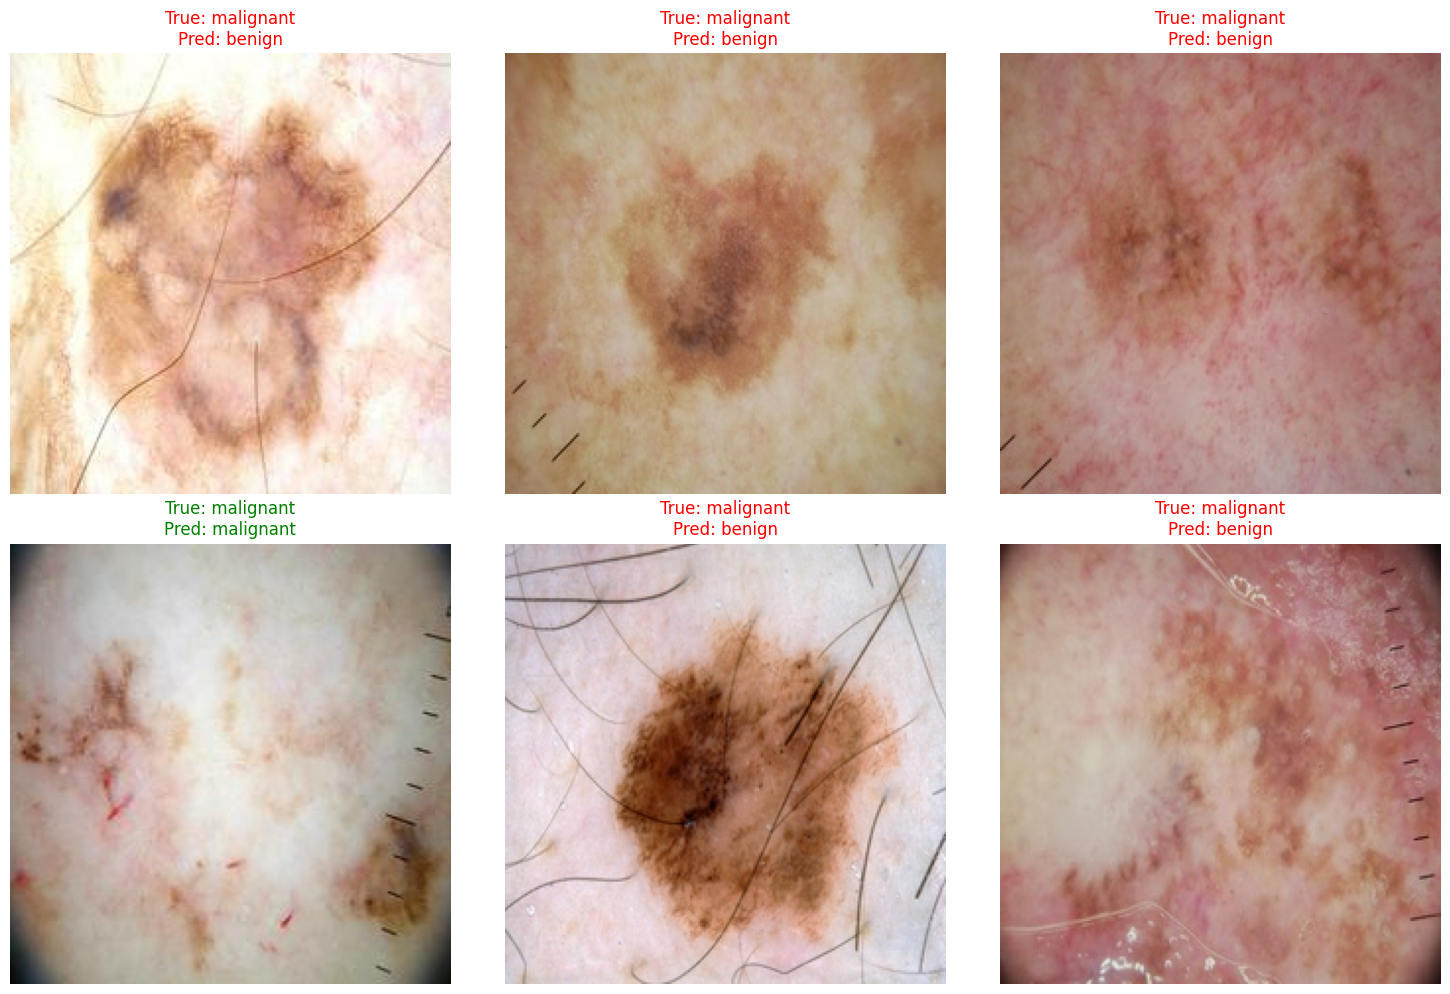

In [29]:
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    plt.figure(figsize=(15, 10))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        pred_label = 'malignant' if predictions[i][0] > 0.5 else 'benign'
        true_label = 'malignant' if labels[i] == 1 else 'benign'
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f'True: {true_label}\nPred: {pred_label}', color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### 7. Evaluate the Model

In [25]:
hist_df = pd.DataFrame(history.history)
hist_df.head()

,AUC,loss,val_AUC,val_loss
0,0.881773,0.708867,0.959459,0.957232
1,0.866900,0.628225,0.891892,0.266138
2,0.923930,0.546510,1.000000,0.586615
3,0.938613,0.445601,1.000000,1.349952
4,0.922224,0.411577,0.986486,2.105947


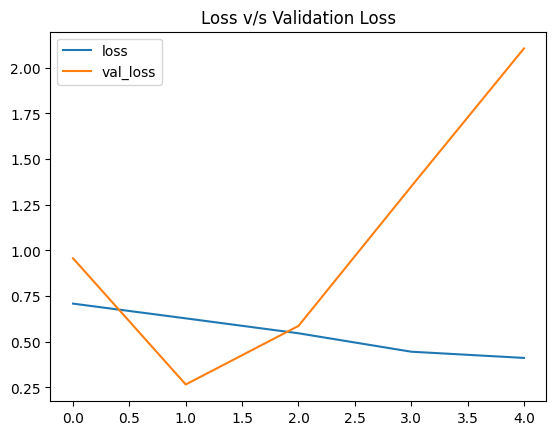

In [26]:
hist_df['loss'].plot()
hist_df['val_loss'].plot()
plt.title('Loss v/s Validation Loss')
plt.legend()
plt.show()

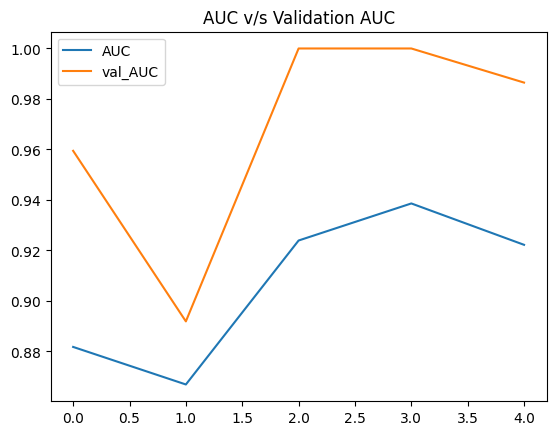

In [28]:
hist_df['AUC'].plot()
hist_df['val_AUC'].plot()
plt.title('AUC v/s Validation AUC')
plt.legend()
plt.show()